# 01 — Entender o artigo e auditar os resultados

**Diffuse2Seg, arXiv:2609.06491v1.** Os números abaixo são transcritos do artigo; não são resultados produzidos por execução de seus modelos. A análise completa está em [analysis.md](../notes/analysis.md).

In [1]:
from pathlib import Path
import json
from IPython.display import display, Image
import os
root = Path(os.environ.get("SEMINAR4_ROOT", "seminar_4")).resolve()
if not root.exists():
    root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
assert (root / "articles/2609.06491v1.pdf").exists()
print("Seminário:", root)

Seminário: /home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/seminar_4


## 1. Hipótese e pipeline

Um gerador pré-treinado captura relações de entidades. O artigo usa sua autoatenção congelada para criar pseudo-máscaras e treina um estudante. O estudante Mask2Former e o gerador SD2 são modelos distintos. A extração usa t=150, imagem sem ruído forward e embeddings de texto nulos.

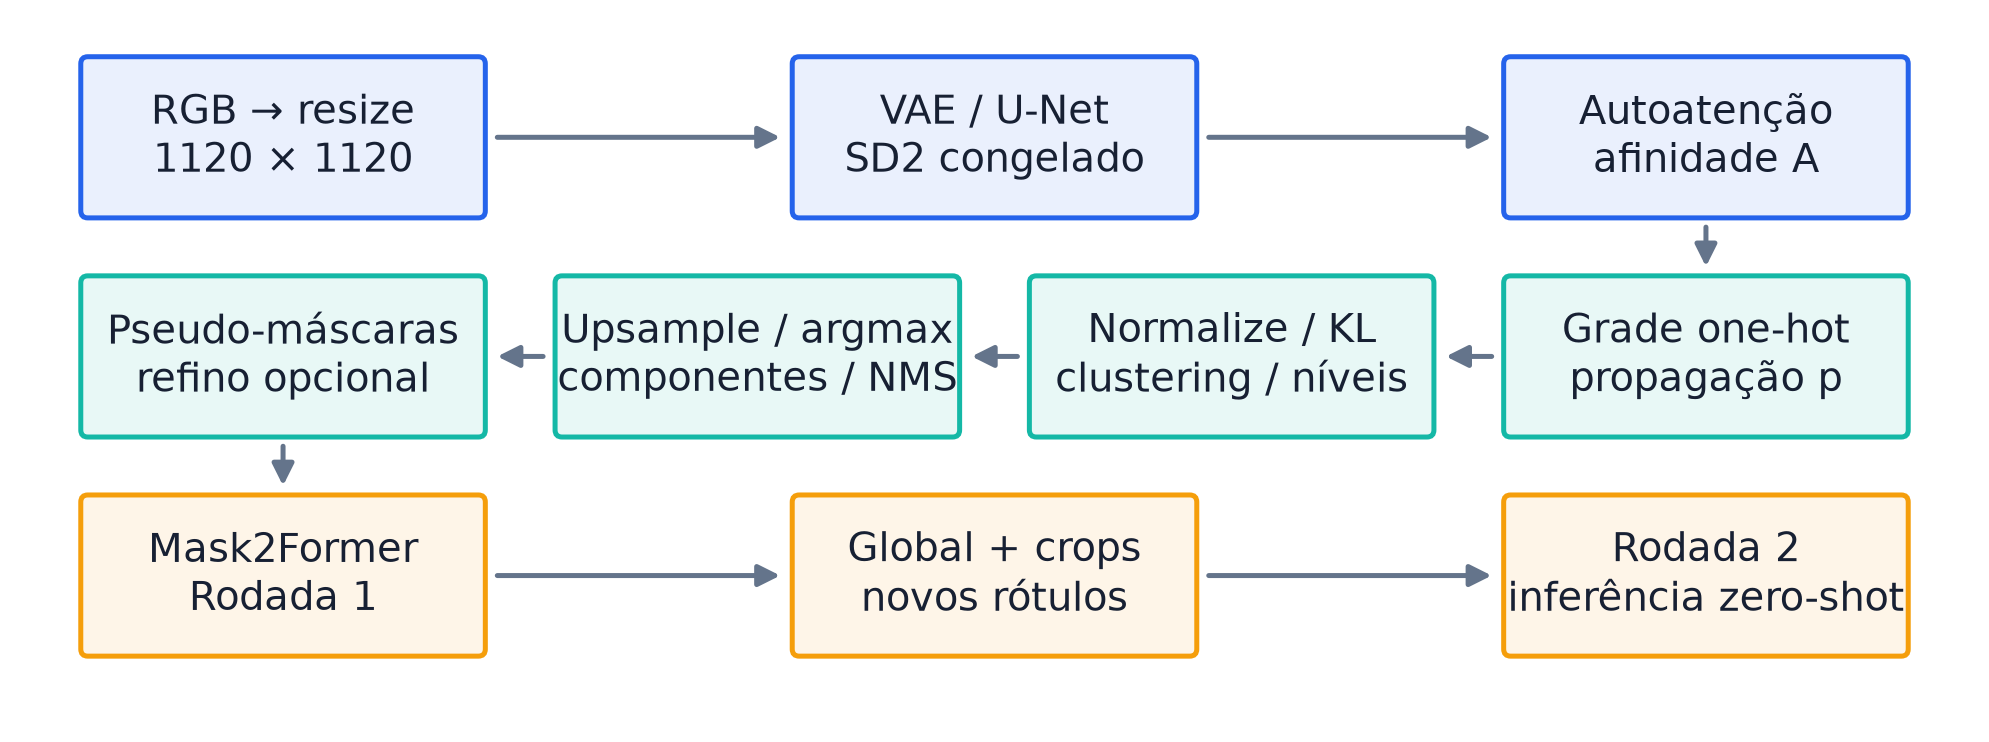

In [2]:
display(Image(filename=str(root / "assets/figures/pipeline.png"), width=1100))

## 2. Propagação

$E(f)=\frac1p\sum_i[\sum_j A_{ij}(f_j-f_i)^2]^{p/2}+\frac\lambda2\|f-f^0\|_2^2$.

p=2 é linear; p<2 altera o comportamento de regularização. Os autores usam p=1,6 para favorecer precisão dos rótulos, não o máximo recall. Grade → mapas suaves → normalização → KL simétrica → ligação média → cortes → upsampling/argmax → componentes → NMS. O refinador de borda é opcional.

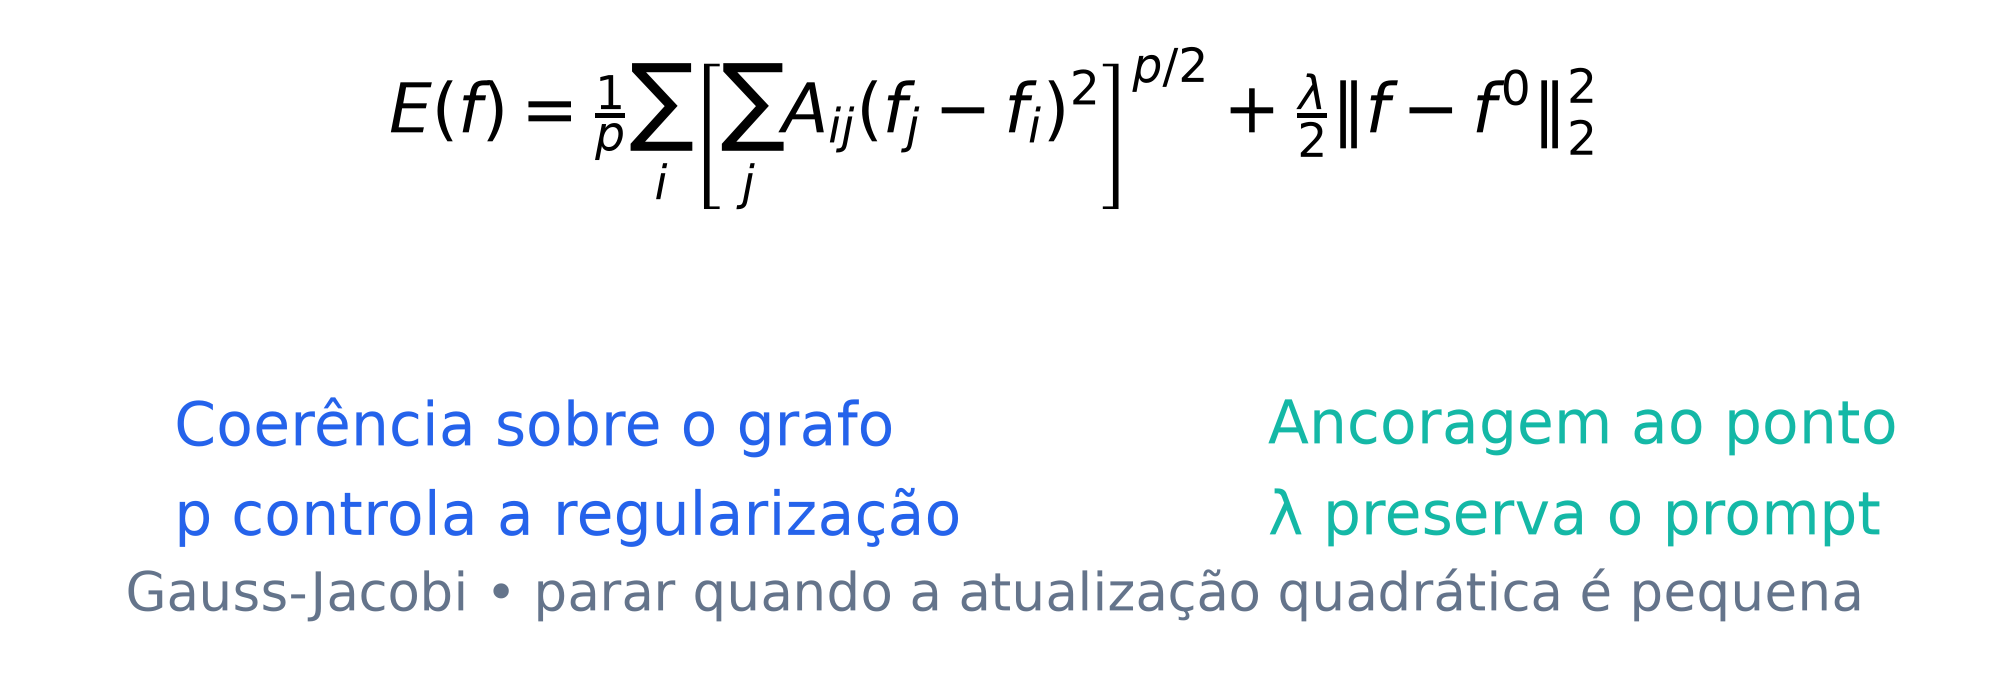

In [3]:
display(Image(filename=str(root / "assets/figures/energy.png"), width=1000))

## 3. Auditoria das tabelas originais

As tabelas 1–5 têm transcrição em JSON e CSV. Não inferimos valores ausentes em curvas. Todos os valores desta seção são em %.

In [4]:
from IPython.display import Markdown
paper = json.loads((root / "data/paper_results.json").read_text())
columns = paper["table2_columns"]
lines = ["| Método | " + " | ".join(columns) + " |", "|---|" + "---:|"*len(columns)]
lines.extend("| " + name + " | " + " | ".join(map(str, values)) + " |" for name, values in paper["table2"].items())
display(Markdown("\n".join(lines)))
gains = [round(o-b, 1) for o, b in zip(paper["table2"]["Diffuse2Seg"], paper["table2"]["UnSAM"], strict=True)]
assert gains == [4.3, 6.5, 4.5, 7.1, 4.3]
print("Ganhos recalculados vs. UnSAM (p.p.):", dict(zip(columns, gains, strict=True)))

| Método | SA-1B | ADE20K | EntitySeg | UVO | PACO |
|---|---:|---:|---:|---:|---:|
| CutLER | 17.0 | 24.8 | 22.1 | 32.3 | 10.7 |
| UnSAM | 16.4 | 16.0 | 19.3 | 22.8 | 9.3 |
| SOHES | 11.0 | 11.6 | 11.6 | 19.3 | 5.2 |
| DiffSeg | 16.0 | 14.1 | 17.5 | 18.9 | 9.8 |
| M2N2 | 9.7 | 18.9 | 19.7 | 29.7 | 9.6 |
| Diffuse2Seg | 20.7 | 22.5 | 23.8 | 29.9 | 13.6 |

Ganhos recalculados vs. UnSAM (p.p.): {'SA-1B': 4.3, 'ADE20K': 6.5, 'EntitySeg': 4.5, 'UVO': 7.1, 'PACO': 4.3}


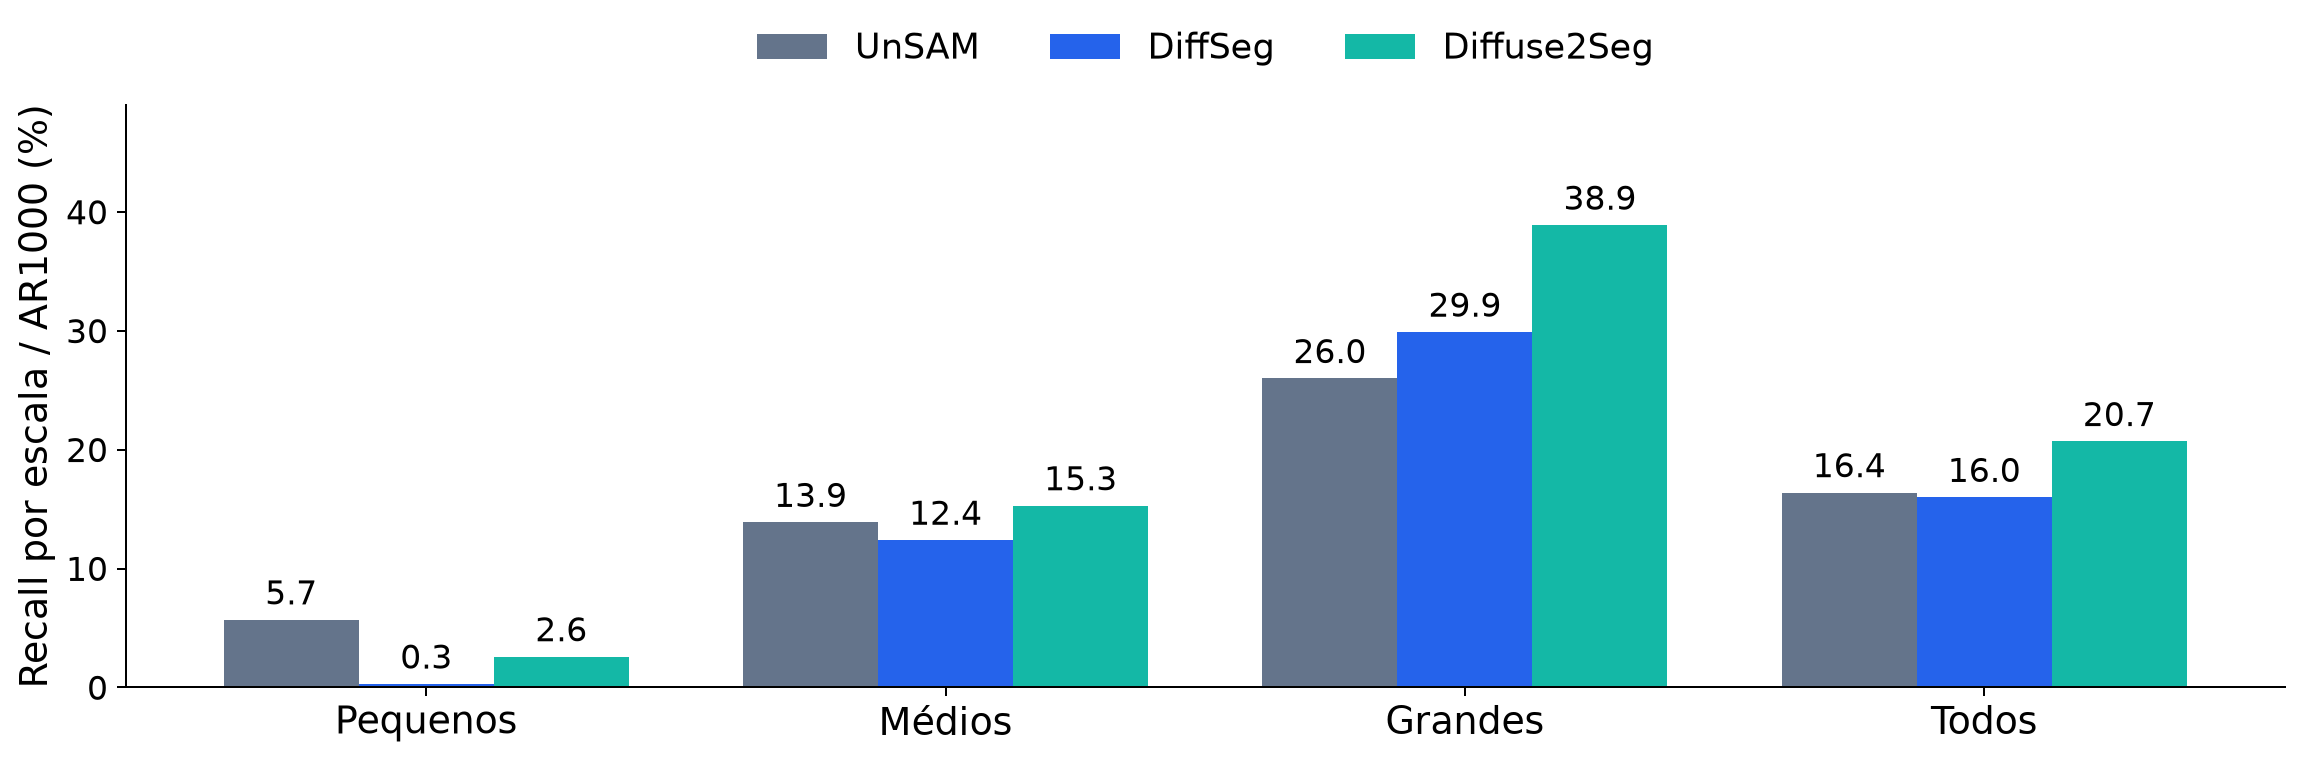

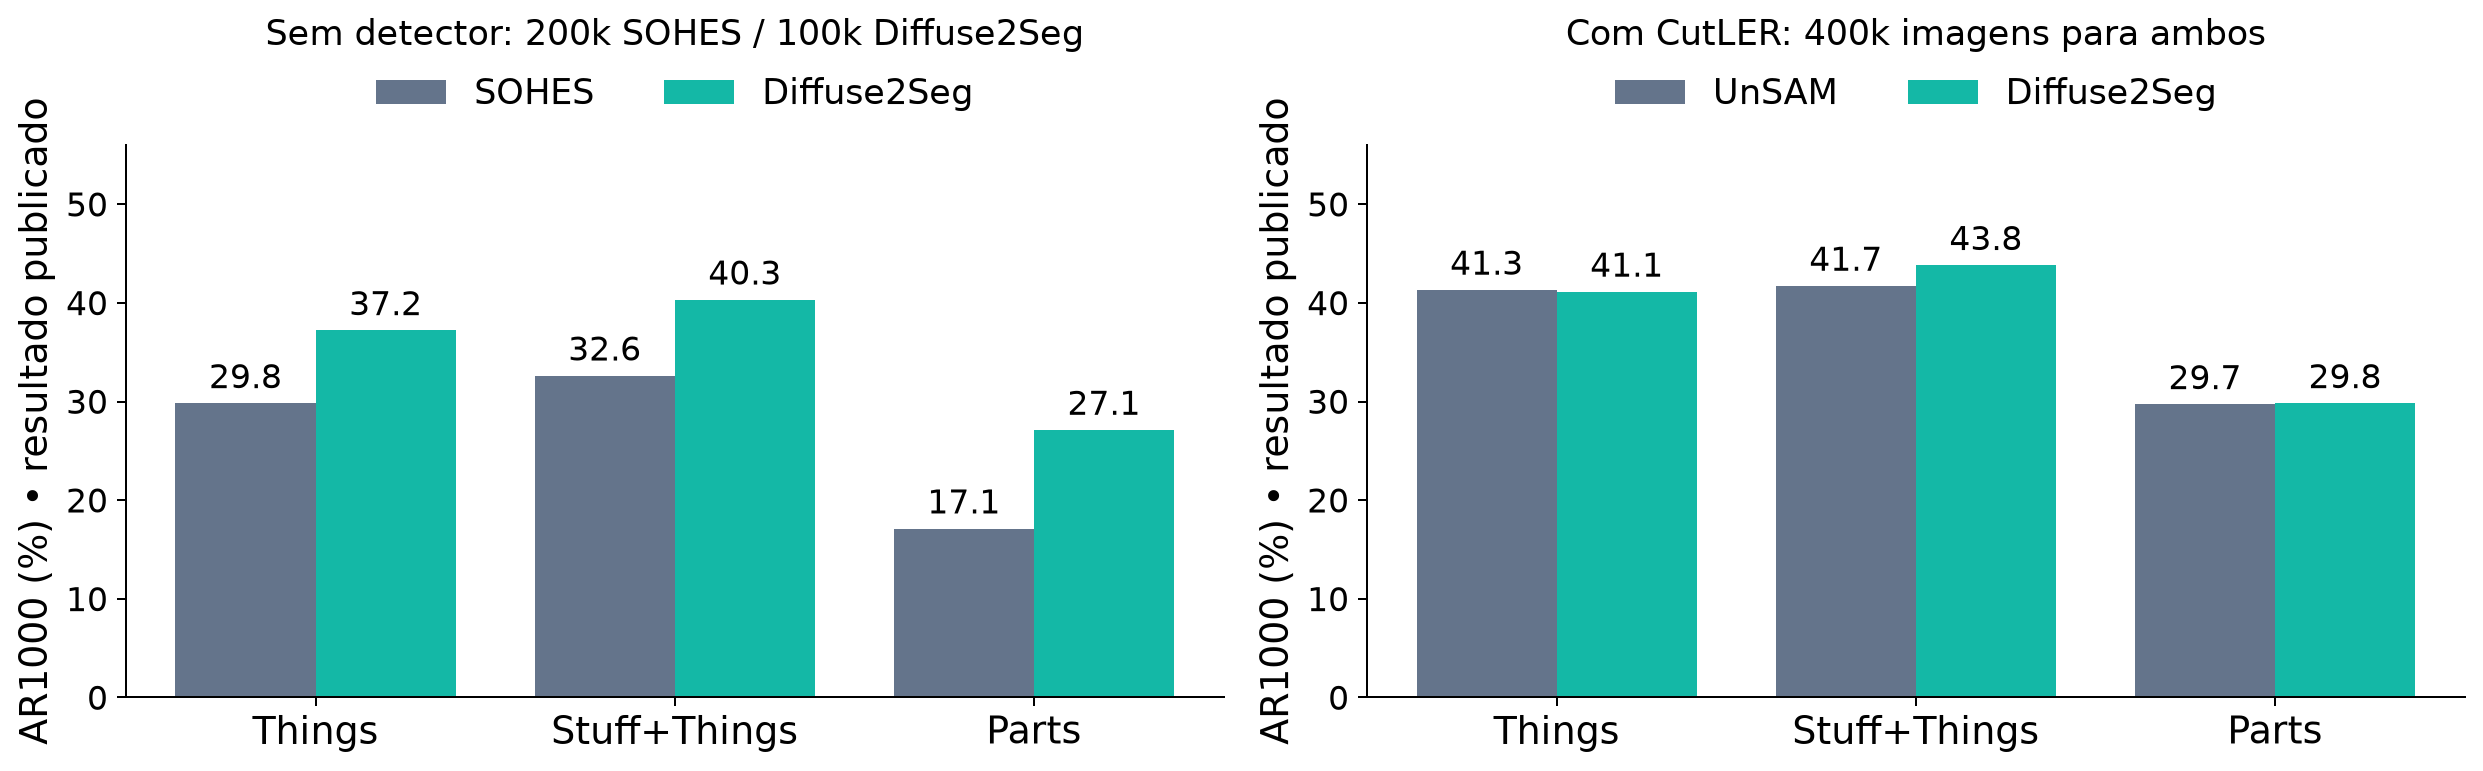

In [5]:
display(Image(filename=str(root / "assets/figures/paper_sizes.png"), width=1000))
display(Image(filename=str(root / "assets/figures/paper_students.png"), width=1100))

## 4. Interpretação crítica

- AR1000 mede recall de até 1.000 propostas; não garante precisão nem classe correta.
- Gerador: AR20,7 na Tabela1; estudante: outros valores na Tabela3.
- UnSAM é melhor em objetos pequenos no gerador.
- Ganhos de fine-tuning pressupõem pré-treinamento e pseudo-rótulos em grande escala.
- Figura5b é normalizada por métrica; não é curva de treino ou AR absoluto.

In [6]:
n = 140*140
bytes_fp32 = n*n*4
print(f"Uma afinidade densa: {n:,} tokens, {bytes_fp32/2**30:.3f} GiB FP32")
print("Cálculo teórico; sem U-Net, cabeças e buffers. Não é medida de VRAM.")

Uma afinidade densa: 19,600 tokens, 1.431 GiB FP32
Cálculo teórico; sem U-Net, cabeças e buffers. Não é medida de VRAM.


## 5. Relação com a pesquisa SAR

[Análise fundamentada](../notes/research_application.md): pistas são uma classe estreita e alongada; as entidades genéricas precisam de seleção semântica. RGB→SAR exige avaliar mudança de domínio. Crops e enriquecimento de pseudo-rótulos podem ser testados antes de trocar arquitetura. Nenhum resultado SAR foi reproduzido nesta atividade.